<a href="https://colab.research.google.com/github/myoohit/IIT-Madras-assignment/blob/main/ChessBoard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()  # upload an image
input_image = list(uploaded.keys())[0]  # get the filename
print("Uploaded:", input_image)

Saving chessboard.jpg to chessboard.jpg
Uploaded: chessboard.jpg


In [3]:
import numpy as np
from PIL import Image
import math

def load_color(path):
    img = Image.open(path).convert('RGB')
    arr = np.asarray(img).astype(np.float32) / 255.0
    arr = np.clip(arr, 1e-6, 1.0)
    return arr

def save_color(img_arr, path):
    arr = np.clip(img_arr, 0.0, 1.0)
    im = Image.fromarray((arr * 255.0).astype(np.uint8))
    im.save(path)

def make_gaussian_kernel(size, sigma):
    assert size % 2 == 1
    k = np.zeros((size, size), dtype=np.float32)
    c = size // 2
    sumv = 0.0
    for i in range(size):
        for j in range(size):
            x = i - c
            y = j - c
            v = math.exp(-(x*x + y*y) / (2 * sigma * sigma))
            k[i, j] = v
            sumv += v
    k /= sumv
    return k

def manual_convolve(img, kernel):
    H, W = img.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(H):
        for j in range(W):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel)
    return out

def color_illum_correct(path_in, path_out, kernel_size=51, sigma=10.0):
    I = load_color(path_in)
    H, W, C = I.shape
    logI = np.log(I)

    channel_offsets = np.zeros(3, dtype=np.float32)
    for c in range(3):
        channel_offsets[c] = np.median(logI[..., c])

    i0 = np.stack([logI[..., c] - channel_offsets[c] for c in range(3)], axis=-1)

    avg = np.median(i0, axis=2)
    kernel = make_gaussian_kernel(kernel_size, sigma)
    l_hat = manual_convolve(avg, kernel)

    r_hat = logI - l_hat[..., None]
    R_hat = np.exp(r_hat)

    R_norm = R_hat / (R_hat.max(axis=(0,1), keepdims=True) + 1e-12)
    save_color(R_norm, path_out)
    print("Saved output:", path_out)

Saved output: corrected.png


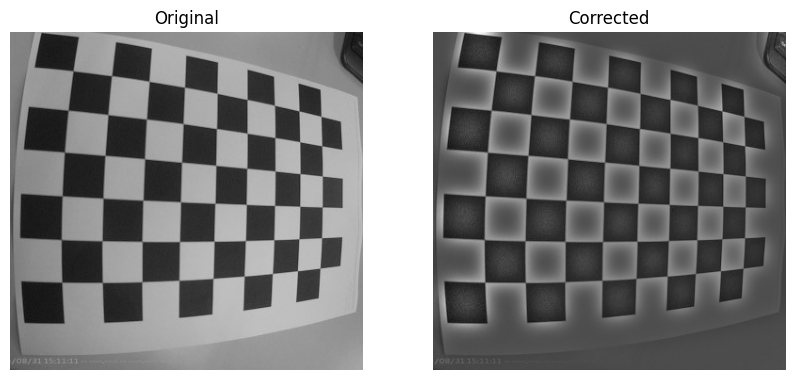

In [4]:
output_image = "corrected.png"
color_illum_correct(input_image, output_image)

# Show before and after
import matplotlib.pyplot as plt

before = np.array(Image.open(input_image))
after = np.array(Image.open(output_image))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(before); plt.axis('off')
plt.subplot(1,2,2); plt.title("Corrected"); plt.imshow(after); plt.axis('off')
plt.show()